# Interpretation of modes recovered from CHAOS-8.6

Fit the selected DMD configuration to CHAOS-8.6 radial secular variation at the CMB, then inspect the recovered spatial phasors, cumulative reconstruction error, equatorial evolution, and geographical power.

## Preamble

In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import os
import sys
from pathlib import Path

import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import matplotlib.pyplot as plt
import numpy as np

cwd = Path(os.getcwd()).resolve()
PROJECT_ROOT = next(
    path for path in (cwd, *cwd.parents)
    if (path / 'src' / 'msc_thesis').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

## DMD configuration and recovered-mode set

The defaults reproduce the selected CHAOS setup: maximum spherical-harmonic degree 9, 99.9% SVD-variance truncation, and Hankel embedding dimension 4. All processed modes with period greater than 3 years are retained, including non-oscillatory modes.

In [33]:
chosen_nmax = 9
chosen_svd_rank = 0.999
chosen_embedding_d = 4
minimum_period = 3.0
wave_period_boundary = 24.0
font_size = 11

chosen_dmd_settings = {
    'dmd_type': 'exact',
    'hankel_flag': True,
    'embedding_d': chosen_embedding_d,
    'weight_flag': True,
}

plt.rcParams.update({
    'font.size': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size,
})

In [34]:
gnm_chaos = CHAOS_Full_SV_Record_Obtain(
    model_version='CHAOS-8.6.mat',
    nmax=chosen_nmax,
)
A_chaos_r = Truncate_Gauss_Coeffs(A_15_r, tmax=chosen_nmax)
gnm_chaos = Truncate_Gauss_Coeffs(gnm_chaos, tmax=chosen_nmax)
chaos_sv_grid = A_chaos_r @ gnm_chaos.T

chaos_dmd_modes = Run_DMD(
    chaos_sv_grid,
    times_used_relative,
    svd_rank=chosen_svd_rank,
    dmd_settings=chosen_dmd_settings.copy(),
)

recovered_periods = np.asarray(chaos_dmd_modes['periods'], dtype=float)
recovered_eigenvalues = np.asarray(
    chaos_dmd_modes['continuous_eigenvalues'],
    dtype=complex,
)
recovered_phasors = np.asarray(chaos_dmd_modes['phasors'], dtype=complex)
static_mask = np.isclose(recovered_eigenvalues.imag, 0.0)
selected_mask = static_mask | (
    np.isfinite(recovered_periods)
    & (recovered_periods > minimum_period)
)
selected_indices = np.flatnonzero(selected_mask)

feasible_indices = selected_indices[
    (~static_mask[selected_indices])
    & (recovered_periods[selected_indices] <= wave_period_boundary)
]
feasible_indices = feasible_indices[
    np.argsort(recovered_periods[feasible_indices])[::-1]
]
long_period_indices = selected_indices[
    (~static_mask[selected_indices])
    & (recovered_periods[selected_indices] > wave_period_boundary)
]
long_period_indices = long_period_indices[
    np.argsort(recovered_periods[long_period_indices])[::-1]
]
static_indices = selected_indices[static_mask[selected_indices]]
long_or_static_indices = np.concatenate([
    long_period_indices,
    static_indices,
]).astype(int)

chaos_mode_suite = {}
for mode_number, mode_index in enumerate(feasible_indices, start=1):
    chaos_mode_suite[f'mode_{mode_number}'] = {
        'label': f'Mode {mode_number}',
        'phasor': recovered_phasors[mode_index],
        'eigenvalue': recovered_eigenvalues[mode_index],
        'period': recovered_periods[mode_index],
        'mode_index': int(mode_index),
        'category': 'feasible',
    }

for long_number, mode_index in enumerate(long_period_indices, start=1):
    chaos_mode_suite[f'long_period_{long_number}'] = {
        'label': f'Long Period Wave {long_number}',
        'phasor': recovered_phasors[mode_index],
        'eigenvalue': recovered_eigenvalues[mode_index],
        'period': recovered_periods[mode_index],
        'mode_index': int(mode_index),
        'category': 'long_period',
    }

for static_number, mode_index in enumerate(static_indices, start=1):
    chaos_mode_suite[f'static_{static_number}'] = {
        'label': f'Static Field {static_number}',
        'phasor': recovered_phasors[mode_index],
        'eigenvalue': recovered_eigenvalues[mode_index],
        'period': np.inf,
        'mode_index': int(mode_index),
        'category': 'static',
    }

feasible_mode_keys = [
    key for key, info in chaos_mode_suite.items()
    if info['category'] == 'feasible'
]
long_or_static_mode_keys = [
    key for key, info in chaos_mode_suite.items()
    if info['category'] in {'long_period', 'static'}
]

print(f"Effective DMD rank: {chaos_dmd_modes['effective_rank']}")
print(f'Retained modes with period > {minimum_period:g} years: '
      f'{len(chaos_mode_suite)}')
for mode_info in chaos_mode_suite.values():
    eigenvalue = mode_info['eigenvalue']
    if mode_info['category'] == 'static':
        period_text = 'no imaginary component'
    else:
        period_text = f"{mode_info['period']:.2f} years"
    print(
        f"  {mode_info['label']}: {period_text}; "
        f"lambda = {eigenvalue.real:.4f} "
        f"{eigenvalue.imag:+.4f}i yr^-1"
    )

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 137441.2668892829. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


Effective DMD rank: 12
Retained modes with period > 3 years: 6
  Mode 1: 15.29 years; lambda = 0.0363 +0.4109i yr^-1
  Mode 2: 7.92 years; lambda = -0.0393 +0.7936i yr^-1
  Mode 3: 5.95 years; lambda = -0.0430 +1.0552i yr^-1
  Mode 4: 4.62 years; lambda = -0.0884 +1.3605i yr^-1
  Long Period Wave 1: 499.47 years; lambda = -0.0687 +0.0126i yr^-1
  Long Period Wave 2: 36.91 years; lambda = -0.1369 +0.1702i yr^-1


## Reconstruction and plotting helpers

`Run_DMD` returns amplitude-scaled processed phasors. Their physical radial-SV contribution is therefore reconstructed at time $t$ after 2000 as $\operatorname{Re}[\phi_j\exp(\lambda_j t)]$.

In [35]:
def Evaluate_Recovered_Mode(mode_info, times=times_used_relative):
    phasor = np.asarray(mode_info['phasor'], dtype=complex).ravel()
    eigenvalue = complex(mode_info['eigenvalue'])
    dynamics = np.exp(eigenvalue * np.asarray(times, dtype=float))
    return np.real(dynamics[:, None] * phasor[None, :])


def Format_Eigenvalue(eigenvalue):
    eigenvalue = complex(eigenvalue)
    sign = '+' if eigenvalue.imag >= 0 else '-'
    return (
        rf'$\lambda={eigenvalue.real:.3f}{sign}'
        rf'{abs(eigenvalue.imag):.3f}i$ yr$^{{-1}}$'
    )


def Period_Text(mode_info):
    if mode_info['category'] == 'static':
        return r'$T = \infty$'
    return f"T = {mode_info['period']:.2f} yr"


longitude_plot = ((np.asarray(longitude) + 180) % 360) - 180
longitude_order = np.argsort(longitude_plot)
longitude_plot = longitude_plot[longitude_order]


def Add_Cyclic_Longitude(field):
    field = np.asarray(field)[..., longitude_order]
    return add_cyclic_point(field, coord=longitude_plot, axis=-1)


def Style_Geographic_Axis(axis):
    axis.set_global()
    axis.coastlines(resolution='110m', color='0.15', linewidth=0.45)
    axis.set_xticks([])
    axis.set_yticks([])


def Plot_CHAOS_Phasors(
    mode_suite,
    mode_keys,
    figure_width=text_width,
    font_size=11,
):
    if not mode_keys:
        raise ValueError('At least one mode is required for a phasor plot.')

    n_modes = len(mode_keys)
    figure_height = 1.12 * n_modes + 0.62
    fig = plt.figure(
        figsize=(figure_width, figure_height),
        constrained_layout=True,
    )
    grid = fig.add_gridspec(
        n_modes + 1,
        3,
        width_ratios=(1.15, 2.35, 2.35),
        height_ratios=([1.0] * n_modes) + [0.10],
    )
    axes = np.empty((n_modes, 2), dtype=object)

    phasor_grids = {}
    colour_values = []
    for mode_key in mode_keys:
        phasor_grid = np.asarray(
            mode_suite[mode_key]['phasor'],
            dtype=complex,
        ).reshape(state_shape)
        real_grid, cyclic_longitude = Add_Cyclic_Longitude(
            phasor_grid.real
        )
        imaginary_grid, _ = Add_Cyclic_Longitude(phasor_grid.imag)
        phasor_grids[mode_key] = (
            real_grid,
            imaginary_grid,
            cyclic_longitude,
        )
        colour_values.extend([real_grid.ravel(), imaginary_grid.ravel()])

    colour_limit = np.nanmax(np.abs(np.concatenate(colour_values)))
    if not np.isfinite(colour_limit) or colour_limit == 0:
        colour_limit = 1.0

    for row, mode_key in enumerate(mode_keys):
        mode_info = mode_suite[mode_key]
        real_grid, imaginary_grid, cyclic_longitude = phasor_grids[mode_key]
        eigenvalue = complex(mode_info['eigenvalue'])
        sign = '+' if eigenvalue.imag >= 0 else '-'

        information_axis = fig.add_subplot(grid[row, 0])
        information_axis.axis('off')
        information_axis.text(
            0.98,
            0.5,
            (
                f"{mode_info['label']}\n"
                rf"$\lambda={eigenvalue.real:.3f}$" '\n'
                rf"${sign}{abs(eigenvalue.imag):.3f}i$ yr$^{{-1}}$" '\n'
                f"{Period_Text(mode_info)}"
            ),
            transform=information_axis.transAxes,
            ha='right',
            va='center',
            fontsize=font_size,
            linespacing=1.15,
        )

        axes[row, 0] = fig.add_subplot(
            grid[row, 1],
            projection=ccrs.Robinson(central_longitude=0),
        )
        axes[row, 1] = fig.add_subplot(
            grid[row, 2],
            projection=ccrs.Robinson(central_longitude=0),
        )
        real_mesh = axes[row, 0].pcolormesh(
            cyclic_longitude,
            latitude,
            real_grid,
            transform=ccrs.PlateCarree(),
            shading='auto',
            cmap='PuOr',
            vmin=-colour_limit,
            vmax=colour_limit,
            rasterized=True,
        )

        if mode_info['category'] == 'static':
            axes[row, 1].text(
                0.5,
                0.5,
                'No imaginary\ncomponent',
                transform=axes[row, 1].transAxes,
                ha='center',
                va='center',
                fontsize=font_size,
            )
        else:
            axes[row, 1].pcolormesh(
                cyclic_longitude,
                latitude,
                imaginary_grid,
                transform=ccrs.PlateCarree(),
                shading='auto',
                cmap='PuOr',
                vmin=-colour_limit,
                vmax=colour_limit,
                rasterized=True,
            )

        for axis in axes[row]:
            Style_Geographic_Axis(axis)
        if row == 0:
            axes[row, 0].set_title('Real', pad=2)
            axes[row, 1].set_title('Imaginary', pad=2)

    colourbar_axis = fig.add_subplot(grid[-1, 1:])
    colourbar = fig.colorbar(
        real_mesh,
        cax=colourbar_axis,
        orientation='horizontal',
    )
    colourbar.set_label(r'Radial SV (nT yr$^{-1}$)')
    colourbar.ax.tick_params(labelsize=font_size)

    return fig, axes


def Plot_Equatorial_And_Power(
    record_suite,
    figure_width=text_width,
    font_size=11,
):
    if not record_suite:
        raise ValueError('At least one reconstructed record is required.')

    equator_indices = np.flatnonzero(np.isclose(latitude, 0.0))
    if equator_indices.size != 1:
        raise ValueError('The DMD grid must contain exactly one 0-degree row.')
    equator_index = int(equator_indices[0])

    n_rows = len(record_suite)
    figure_height = max(1.35 * n_rows + 0.65, 2.35)
    fig = plt.figure(
        figsize=(figure_width, figure_height),
        constrained_layout=True,
    )
    grid = fig.add_gridspec(
        n_rows + 1,
        2,
        height_ratios=([1.0] * n_rows) + [0.11],
        width_ratios=(1.0, 1.0),
    )
    axes = []
    expected_shape = (len(times_used), np.prod(state_shape))
    prepared_records = {}
    equatorial_values = []
    power_values = []

    for label, record in record_suite.items():
        record = np.asarray(record, dtype=float)
        if record.shape != expected_shape:
            raise ValueError(
                f"Record '{label}' has shape {record.shape}; "
                f"expected {expected_shape}."
            )
        record_grid = record.reshape(len(times_used), *state_shape)
        equatorial_sv = record_grid[:, equator_index, :][:, longitude_order]
        mean_power = np.mean(record_grid ** 2, axis=0)
        power_grid, cyclic_longitude = Add_Cyclic_Longitude(mean_power)
        prepared_records[label] = (
            equatorial_sv,
            power_grid,
            cyclic_longitude,
        )
        equatorial_values.append(equatorial_sv.ravel())
        power_values.append(power_grid.ravel())

    equatorial_limit = np.nanmax(np.abs(np.concatenate(
        equatorial_values
    )))
    power_limit = np.nanmax(np.concatenate(power_values))
    if not np.isfinite(equatorial_limit) or equatorial_limit == 0:
        equatorial_limit = 1.0
    if not np.isfinite(power_limit) or power_limit == 0:
        power_limit = 1.0

    time_extent = (
        -180,
        180,
        times_used[-1] + dt_sample / 2,
        times_used[0] - dt_sample / 2,
    )
    for row, label in enumerate(record_suite):
        equatorial_sv, power_grid, cyclic_longitude = prepared_records[label]
        equatorial_axis = fig.add_subplot(grid[row, 0])
        equatorial_image = equatorial_axis.imshow(
            equatorial_sv,
            origin='upper',
            aspect='auto',
            extent=time_extent,
            cmap='seismic',
            vmin=-equatorial_limit,
            vmax=equatorial_limit,
            interpolation='nearest',
            rasterized=True,
        )
        equatorial_axis.set_ylabel(f'{label}\nYear')
        equatorial_axis.set_yticks([2000, 2008, 2016, 2024])
        equatorial_axis.set_xlim(-180, 180)
        equatorial_axis.set_xticks([-180, -90, 0, 90, 180])
        if row == 0:
            equatorial_axis.set_title('Equatorial radial SV', pad=2)
        if row == n_rows - 1:
            equatorial_axis.set_xlabel('Longitude (°)')
        else:
            equatorial_axis.tick_params(labelbottom=False)

        power_axis = fig.add_subplot(
            grid[row, 1],
            projection=ccrs.Robinson(central_longitude=0),
        )
        power_mesh = power_axis.pcolormesh(
            cyclic_longitude,
            latitude,
            power_grid,
            transform=ccrs.PlateCarree(),
            shading='auto',
            cmap='magma',
            vmin=0,
            vmax=power_limit,
            rasterized=True,
        )
        Style_Geographic_Axis(power_axis)
        if row == 0:
            power_axis.set_title('Mean radial-SV power', pad=2)
        axes.append((equatorial_axis, power_axis))

    equatorial_colourbar = fig.colorbar(
        equatorial_image,
        cax=fig.add_subplot(grid[-1, 0]),
        orientation='horizontal',
    )
    equatorial_colourbar.set_label(r'Radial SV (nT yr$^{-1}$)')
    power_colourbar = fig.colorbar(
        power_mesh,
        cax=fig.add_subplot(grid[-1, 1]),
        orientation='horizontal',
    )
    power_colourbar.set_label(r'Mean power ((nT yr$^{-1}$)$^2$)')

    return fig, np.asarray(axes, dtype=object)

## Recovered spatial phasors

The two figures together retain every recovered processed mode with period greater than 3 years. Mode information is kept outside the maps, and each figure uses one shared symmetric `PuOr` radial-SV colour scale.

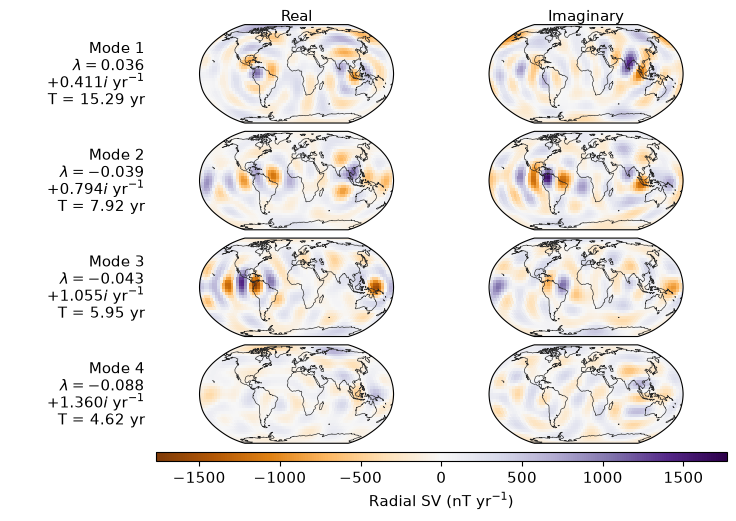

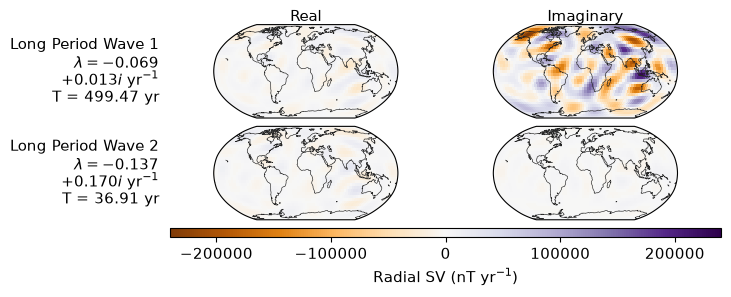

In [36]:
feasible_phasor_figure, feasible_phasor_axes = Plot_CHAOS_Phasors(
    chaos_mode_suite,
    feasible_mode_keys,
    figure_width=text_width,
    font_size=font_size,
)
plt.show()

long_phasor_figure, long_phasor_axes = Plot_CHAOS_Phasors(
    chaos_mode_suite,
    long_or_static_mode_keys,
    figure_width=text_width,
    font_size=font_size,
)
plt.show()

## Cumulative DMD reconstruction misfit

The radial-SV residual is evaluated on the same 5° CMB grid used for DMD. At each time, the plotted metric is the area-weighted root-mean-square residual

$$
E_{\mathrm{RMS}}(t)=\left[\frac{\sum_i w_i\left(B_{r,i}^{\mathrm{CHAOS}}(t)-B_{r,i}^{\mathrm{DMD}}(t)\right)^2}{\sum_i w_i}\right]^{1/2},
\qquad w_i=\cos(\mathrm{latitude}_i).
$$

The first reconstruction contains every long-period or static contribution. Feasible modes are then added from longest to shortest period; Mode 1 is the longest feasible mode.

In [37]:
mode_records = {
    mode_key: Evaluate_Recovered_Mode(mode_info)
    for mode_key, mode_info in chaos_mode_suite.items()
}
chaos_record = chaos_sv_grid.T
expected_record_shape = (len(times_used), np.prod(state_shape))
if chaos_record.shape != expected_record_shape:
    raise ValueError(
        f'CHAOS record has shape {chaos_record.shape}; '
        f'expected {expected_record_shape}.'
    )

long_period_sum = np.zeros_like(chaos_record, dtype=float)
for mode_key in long_or_static_mode_keys:
    long_period_sum += mode_records[mode_key]

cumulative_records = {'LP': long_period_sum.copy()}
running_sum = long_period_sum.copy()
included_mode_numbers = []
for mode_number, mode_key in enumerate(feasible_mode_keys, start=1):
    running_sum = running_sum + mode_records[mode_key]
    included_mode_numbers.append(str(mode_number))
    cumulative_label = 'LP+' + '+'.join(included_mode_numbers)
    cumulative_records[cumulative_label] = running_sum.copy()

area_weights = np.asarray(W2D_norm, dtype=float).ravel()
if area_weights.size != chaos_record.shape[1]:
    raise ValueError('Area weights do not match the DMD spatial grid.')
if not np.isclose(np.sum(area_weights), 1.0):
    raise ValueError('Expected normalized area weights to sum to one.')

cumulative_rms_misfit = {}
for label, reconstruction in cumulative_records.items():
    residual = chaos_record - reconstruction
    cumulative_rms_misfit[label] = np.sqrt(
        np.sum(area_weights[None, :] * residual ** 2, axis=1)
    )

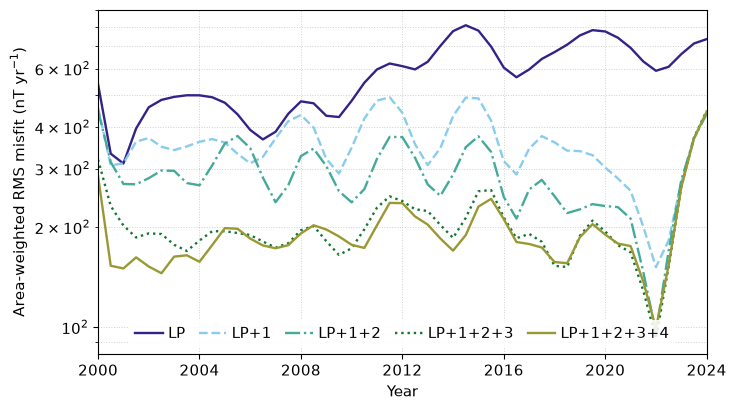

In [38]:
misfit_figure, misfit_axis = plt.subplots(
    figsize=(text_width, 0.55 * text_width),
    constrained_layout=True,
)
line_styles = ['-', '--', '-.', ':']
for line_index, (label, rms_misfit) in enumerate(
    cumulative_rms_misfit.items()
):
    misfit_axis.semilogy(
        times_used,
        rms_misfit,
        color=tol_muted[line_index % len(tol_muted)],
        linestyle=line_styles[line_index % len(line_styles)],
        linewidth=1.7,
        label=label,
    )
misfit_axis.set(
    xlim=(times_used[0], times_used[-1]),
    xlabel='Year',
    ylabel=r'Area-weighted RMS misfit (nT yr$^{-1}$)',
)
misfit_axis.set_xticks(np.arange(2000, 2025, 4))
misfit_axis.grid(True, which='both', linestyle=':', linewidth=0.7, alpha=0.6)
misfit_axis.legend(
    frameon=True,
    framealpha=0.88,
    edgecolor='none',
    ncol=len(cumulative_rms_misfit),
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    borderaxespad=0.2,
    columnspacing=0.9,
    handlelength=1.8,
    handletextpad=0.35,
)
plt.show()

## Feasible-wave equatorial evolution and geographical power

The left panels use the exact 0° latitude row of the DMD grid. The right panels show mean reconstructed radial-SV power, $\langle B_r^2\rangle_t$, over 2000–2024.

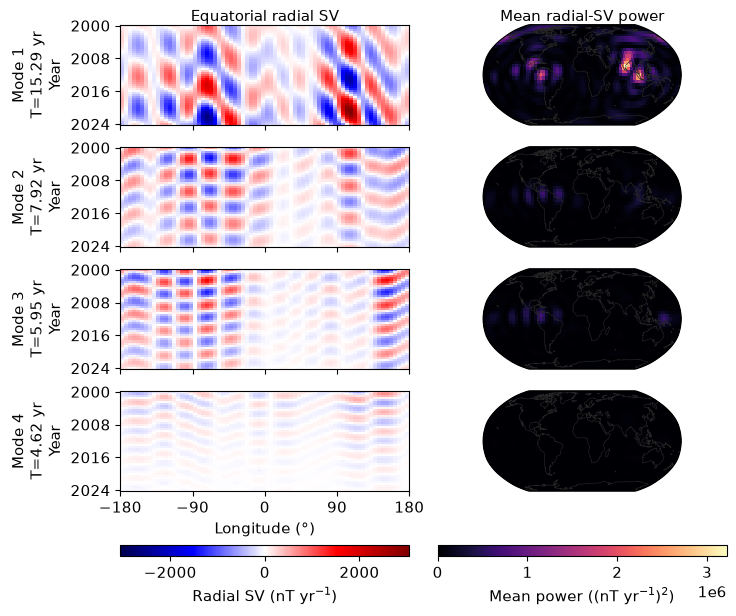

In [39]:
feasible_record_suite = {
    (
        f"{chaos_mode_suite[mode_key]['label']}\n"
        f"T={chaos_mode_suite[mode_key]['period']:.2f} yr"
    ): mode_records[mode_key]
    for mode_key in feasible_mode_keys
}
evolution_figure, evolution_axes = Plot_Equatorial_And_Power(
    feasible_record_suite,
    figure_width=text_width,
    font_size=font_size,
)
plt.show()

## Combined two shortest-period waves

The two shortest feasible DMD contributions are superposed before calculating their equatorial evolution and geographical power.

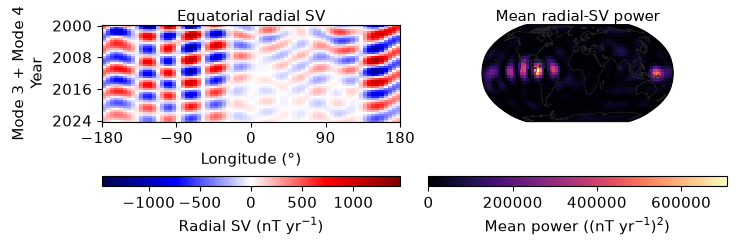

In [40]:
if len(feasible_mode_keys) < 2:
    raise ValueError(
        'At least two feasible waves are required for the combined plot.'
    )
shortest_mode_keys = feasible_mode_keys[-2:]
combined_short_record = np.sum(
    [mode_records[mode_key] for mode_key in shortest_mode_keys],
    axis=0,
)
combined_short_label = ' + '.join(
    chaos_mode_suite[mode_key]['label']
    for mode_key in shortest_mode_keys
)
combined_short_figure, combined_short_axes = Plot_Equatorial_And_Power(
    {combined_short_label: combined_short_record},
    figure_width=text_width,
    font_size=font_size,
)
plt.show()